In [ ]:
# !pip install moomoo-api
# !pip install matplotlib inline
# !pip install finnhub-python
# !pip install python-dotenv
# !pip install seaborn
# !pip install playwright
# !playwright install chromium

# 牛来

In [1]:
from moomoo import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import concurrent.futures
import urllib.request

# quote_ctx gets the market data from moomoo server, and trade_ctx gets the trading data from moomoo server.
quote_ctx = OpenQuoteContext(host='127.0.0.1', port=11111)  # Create quote object
print(quote_ctx.get_market_snapshot('HK.00700'))  # Get market snapshot for HK.00700
quote_ctx.close() # Close object to prevent the number of connextions from running out
print("----------------------------------------------")
trd_ctx = OpenSecTradeContext(host='127.0.0.1', port=11111)  # Create trade object
print(trd_ctx.place_order(price=500.0, qty=100, code="HK.00700", trd_side=TrdSide.BUY, trd_env=TrdEnv.SIMULATE))  # Placing an order through paper trading account (Live trading requires unlocking first; if using the GUI version of OpenD, skip this step and unlock manually by clicking the Unlock button on the UI)

trd_ctx.close()  # Close object to prevent the number of connextions from running out

2026-09-17 14:27:54,423 | 84113 | 138740171802112 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7506237480175824193(1) context=<moomoo.quote.open_quote_context.OpenQuoteContext object at 0x7e2e96b806e0>
(0,        code     name          update_time  last_price  open_price  high_price  \
0  HK.00700  TENCENT  2026-09-17 14:27:52       426.0       426.2       431.0   

   low_price  prev_close_price      volume      turnover  ...  \
0      425.0             433.4  11156989.0  4.761742e+09  ...   

   after_change_rate  after_amplitude overnight_price  overnight_high_price  \
0                N/A              N/A             N/A                   N/A   

   overnight_low_price  overnight_volume  overnight_turnover  \
0                  N/A               N/A                 N/A   

   overnight_change_val  overnight_change_rate  overnight_amplitude  
0                   N/A                    N/A                  N/A  

[1 rows x 142 columns])
-------------------

## Sentiment correlation in financial news networks and associated market movements pipeline

In [2]:
# load finnhub news
import os
from dotenv import load_dotenv
import finnhub
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import json
from playwright.async_api import async_playwright
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo

load_dotenv(dotenv_path = '../main/.env')  
FINNHUB_API_KEY = os.getenv('FINNHUB_API_KEY')
# today_date = datetime.datetime.now().strftime("%Y-%m-%d")

finnhub_client = finnhub.Client(api_key=FINNHUB_API_KEY)

def date_days_ago(days, curr_date):
    return (curr_date - timedelta(days=days)).strftime("%Y-%m-%d")

def get_sixtyd_rolling_window(company_code):
    # uese us market open date to avoid lookahead bias
    us_market_time_open = datetime.now(ZoneInfo("America/New_York")).replace(hour=9, minute=30, second=0, microsecond=0)
    us_market_time_open_date = us_market_time_open.strftime("%Y-%m-%d")
    sixtyd_ago_date = date_days_ago(60, us_market_time_open)
    us_market_time_open_ts = int(us_market_time_open.timestamp())
    sixtyd_window_news = finnhub_client.company_news(company_code, _from=sixtyd_ago_date, to=us_market_time_open_date)
    # filter
    filtered_sixtyd_window_news = [article for article in sixtyd_window_news if article['datetime'] < us_market_time_open_ts]
    return filtered_sixtyd_window_news


sixtyd_window_news_amzn = get_sixtyd_rolling_window('AMZN')

print(len(sixtyd_window_news_amzn))

sixtyd_window_news_amzn[0:5]

248


[{'category': 'company',
  'datetime': 1789602771,
  'headline': 'What Has Home Depot Stopped Telling You About Where Its Goods Come From?',
  'id': 142202282,
  'image': 'https://s.yimg.com/rz/stage/p/yahoo_finance_en-US_h_p_finance_2.png',
  'related': 'AMZN',
  'source': 'Yahoo',
  'summary': 'Home Depot (HD) stock has lost about a quarter of its value over the past year, while the S&P 500 gained close to 17%. Where the goods on its shelves come from used to be something management explained at length. Now you mostly hear how fast they arrive.',
  'url': 'https://finnhub.io/api/news?id=7db065353067f2401e1567db112c19c1b4a833b3f158bbe1fe04c1d8a4fe5b3c'},
 {'category': 'company',
  'datetime': 1789598355,
  'headline': 'The Next Short? Economist Compares Hyperscaler AI Debt Stress to 2008 Housing Collapse',
  'id': 142200892,
  'image': 'https://s.yimg.com/rz/stage/p/yahoo_finance_en-US_h_p_finance_2.png',
  'related': 'AMZN',
  'source': 'Yahoo',
  'summary': "Apollo's Torsten Slok wa

In [114]:
# 
us_company_codes = [
    # cloud
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NFLX", "CRM", "ORCL",
    # chips
    "NVDA", "AMD", "AVGO", "INTC", "CSCO", "IBM",
    # retail
    "TSLA", "WMT", "TGT", "COST", "MCD", "SBUX", "GM", "HD",
    # banking
    "JPM", "GS", "MS", "BAC", "WFC", "AXP", "V", "MA", "BRK.B",
    # sector anchor
    "PG", "KO", "PEP", "JNJ", "PFE", "LLY", "UNH", "GE", "CAT", "BA", "XOM", "CVX"

]

news_metadata = []


for code in us_company_codes:
    try:
        news = get_sixtyd_rolling_window(code)
        news_metadata  += news
        print(f"company {code} processed! Total of {len(news)} news")
    except Exception as e:
        print('error processing: '+ code + f"\n{e}")

dedup = list({article['id']: article for article in news_metadata}.values())

# write to json
with open('news_metadata.json', 'w') as f:
    json.dump(dedup, f)

len(dedup)

company AAPL processed! Total of 242 news
company MSFT processed! Total of 248 news
company GOOGL processed! Total of 249 news
company AMZN processed! Total of 249 news
company META processed! Total of 244 news
company NFLX processed! Total of 240 news
company CRM processed! Total of 241 news
company ORCL processed! Total of 249 news
company NVDA processed! Total of 239 news
company AMD processed! Total of 246 news
company AVGO processed! Total of 245 news
company INTC processed! Total of 243 news
company CSCO processed! Total of 230 news
company IBM processed! Total of 232 news
company TSLA processed! Total of 237 news
company WMT processed! Total of 246 news
company TGT processed! Total of 246 news
company COST processed! Total of 247 news
company MCD processed! Total of 228 news
company SBUX processed! Total of 246 news
company GM processed! Total of 249 news
company HD processed! Total of 237 news
company JPM processed! Total of 243 news
company GS processed! Total of 232 news
comp

7962

In [4]:
# from datetime import datetime, timedelta
# from zoneinfo import ZoneInfo



# def update_cached_news_metadata(finnhub_client):

#     cached_news_metadata = None
#     with open('news_metadata.json', 'r') as f:
#         cached_news_metadata = json.load(f)

#     all_dates = [article['datetime'] for article in cached_news_metadata]
#     latest_cached_date_ts = max(all_dates)

#     latest_cached_date = datetime.fromtimestamp(latest_cached_date_ts).strftime("%Y-%m-%d")

#     # use the US market time opening time
#     us_market_time_open = datetime.now(ZoneInfo("America/New_York")).replace(hour=9, minute=30, second=0, microsecond=0)
#     sixtyd_from_us_date = us_market_time_open- timedelta(60)

#     us_market_time_open_date = us_market_time_open.strftime("%Y-%m-%d")
#     us_market_time_open_ts = int(us_market_time_open.timestamp())
#     sixtyd_from_us_date_ts = int(sixtyd_from_us_date.timestamp())

#     us_company_codes = [
#         # cloud
#         "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NFLX", "CRM", "ORCL",
#         # chips
#         "NVDA", "AMD", "AVGO", "INTC", "CSCO", "IBM",
#         # retail
#         "TSLA", "WMT", "TGT", "COST", "MCD", "SBUX", "GM", "HD",
#         # banking
#         "JPM", "GS", "MS", "BAC", "WFC", "AXP", "V", "MA", "BRK.B",
#         # sector anchor
#         "PG", "KO", "PEP", "JNJ", "PFE", "LLY", "UNH", "GE", "CAT", "BA", "XOM", "CVX"
#         ]

#     # filter away the timestamps that are before this date
#     print("removing articles outside the roling 60 day date window...")
#     filtered_cached_news_metadata = [article for article in cached_news_metadata if article['datetime'] > sixtyd_from_us_date_ts]

#     # populate the filtered list with new news
#     for code in us_company_codes:
#         try:
#             data = finnhub_client.company_news(code, _from=latest_cached_date, to=us_market_time_open_date)
#             filtered_cached_news_metadata += data
#             print(f"company {code} processed! Total of {len(data)} news")
#         except Exception as e:
#              print(e)
             

#     # second filtering to filter away articles after the market open date today
#     filtered_cached_news_metadata = [article for article in filtered_cached_news_metadata if article['datetime'] < us_market_time_open_ts]

#     # remove dups
#     dedup_filtered_cached_news_metadata = list({article['id']: article for article in filtered_cached_news_metadata}.values())
#     print(f"dups resolved from {len(filtered_cached_news_metadata)} to {len(dedup_filtered_cached_news_metadata)}")

#     # write to json
#     with open('news_metadata.json', 'w') as f:
#         try:
#             json.dump(dedup_filtered_cached_news_metadata, f)
#         except Exception as e:
#                 print('error processing: '+ code + f"\n{e}")

#     print("metadata successfully updated!")


# update_cached_news_metadata(finnhub_client)

In [3]:
# load news from cache
cached_news_metadata = None
with open('news_metadata.json', 'r') as f:
    cached_news_metadata = json.load(f)

cached_news_articles = None
with open('news_articles.json', 'r') as f:
    cached_news_articles = json.load(f)

def load_url(url, timeout):
    headers = {
        "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9",
    }

    response = requests.get(url, headers=headers, timeout=timeout)
    response.raise_for_status()

    return response.content

def get_text_from_html(data):
    soup = BeautifulSoup(data, 'html.parser')
    paragraphs = soup.find_all("p")
    article_text = "\n".join(p.get_text(" ", strip=True).lower() for p in paragraphs)
    return article_text


cached_news_articles = None
with open('news_articles.json', 'r') as f:
    cached_news_articles = json.load(f)

# articles that have not been processed and insdie the metadata
urls = list(set([news['url'] for news in cached_news_metadata if news['url'] not in cached_news_articles]))


print(f"processing {len(urls)} urls")
completed = 0
with concurrent.futures.ThreadPoolExecutor(max_workers=7) as executor:
    # Start the load operations and mark each future with its URL
    future_to_url = {executor.submit(load_url, url, 30): url for url in urls}
    for future in concurrent.futures.as_completed(future_to_url):
        url = future_to_url[future]
        try:
            data = future.result()

            # convert to text
            article_text = get_text_from_html(data)

            # append to list
            if article_text:
                cached_news_articles[url] = article_text
                print(f"{url} successfully processed!")

        except Exception as exc:
            print('%r generated an exception: %s' % (url, exc))

        completed += 1
        if completed % 25 == 0:
            print(f"{completed}/{len(urls)} completed")

# remove articles not present in the metadata
metadata_urls = [news['url'] for news in cached_news_metadata]
filtered_cached_news_articles = {url: text for url, text in cached_news_articles.items() if url in metadata_urls}

with open('news_articles.json', 'w') as f:
    json.dump(filtered_cached_news_articles , f)

len(cached_news_articles),"to", len(filtered_cached_news_articles)

processing 2759 urls
'https://finnhub.io/api/news?id=b9a56a0ca8e9a078d12ec1d242be818fcd9abfe1950887d262d7928fd40598c5' generated an exception: 403 Client Error: Forbidden for url: https://247wallst.com/investing/2026/09/16/the-ai-stock-that-could-beat-nvidia-by-2027/
'https://finnhub.io/api/news?id=c128f5740c2b1806da479739d8d51782324d70847819d8e6899462891d2c67c2' generated an exception: 403 Client Error: Forbidden for url: https://247wallst.com/investing/2026/09/08/bonds-just-posted-their-worst-decade-since-the-great-depression-is-this-the-buying-opportunity-of-a-generation/
'https://finnhub.io/api/news?id=29052b590d1b155e877b34c54d136a98ecd7d2418be4d4b61ca0ca21e14607d2' generated an exception: 403 Client Error: Forbidden for url: https://247wallst.com/investing/2026/08/07/how-tactical-buyers-should-play-costco-today/
'https://finnhub.io/api/news?id=d821161ab4cb812716c845312ec6cc0f70948995cae9b7ba6aad95201c268fd4' generated an exception: 403 Client Error: Forbidden for url: https://see

(7255, 'to', 6431)

In [ ]:
cached_news_articles = None
with open('news_articles.json', 'r') as f:
    cached_news_articles = json.load(f)

cached_news_articles['https://finnhub.io/api/news?id=09613e0f024d6e9a93a4fae59e397966020f784dac0f8568f0939d08ead595db']

'oops, something went wrong\nmagnolia oil & gas (mgy) said monday that it has signed a definitive agreement to acquire wildfire e'

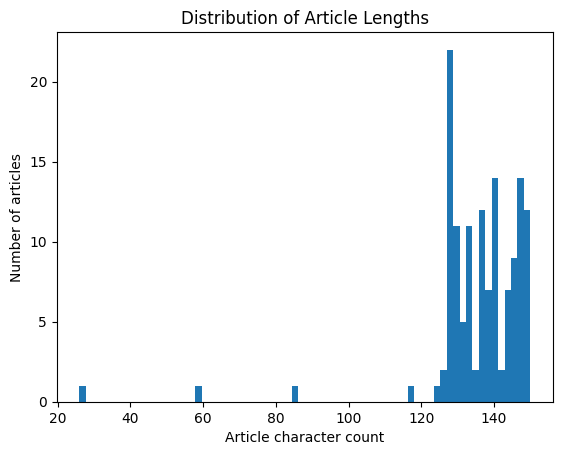

In [4]:
import matplotlib.pyplot as plt

lengths = [len(text) for text in filtered_cached_news_articles.values() if len(text) <= 150 and 'oops, something went wrong' in text]

plt.hist(lengths, bins=70)
plt.xlabel("Article character count")
plt.ylabel("Number of articles")
plt.title("Distribution of Article Lengths")
plt.show()

print()

In [5]:
ct = 0
for url, text in cached_news_articles.items():
    if len(text) <= 128 and 'oops, something went wrong' in text:
        print("=" * 100)
        print("Length:", len(text))
        print("URL:", url)
        print("TEXT:", repr(text))
        ct += 1
ct

Length: 85
URL: https://finnhub.io/api/news?id=f82b5af8e393a17885549231c43f3cc1a7d77ea538f549e55695793b8f81b696
TEXT: 'oops, something went wrong\nno news stories available\nsign in to access your portfolio'
Length: 59
URL: https://finnhub.io/api/news?id=19a181ba26768450407baf30a75c6e78bb4bad8e0b2b60956b38bd5267bc4049
TEXT: 'oops, something went wrong\nsign in to access your portfolio'
Length: 127
URL: https://finnhub.io/api/news?id=41395eb04231ea23c262e52408bb6641457a13852b199aa26806a20a6c85740d
TEXT: 'oops, something went wrong\nhealthcare stocks were edging higher pre-bell wednesday, with the state street health care select se'
Length: 127
URL: https://finnhub.io/api/news?id=f170b3df6972343cca61f3e354f0bf4891679a5ca3be81367d1bd7db48eb7ac7
TEXT: "oops, something went wrong\nalphabet's (goog, googl) google will be questioned by india's police after finding that a criminal n"
Length: 127
URL: https://finnhub.io/api/news?id=a0f13dd5872071e48126d8f286cf349883f0aa21324db1d5f38cc039ab90448

29

In [ ]:
data = load_url("https://finnhub.io/api/news?id=25aeb44b56fdd20c2fbb9f307c3b06084c52f1427f4e9e95d1593db372bd106b", 20)
# get_text_from_html(data)
soup = BeautifulSoup(data, 'html.parser')
paragraphs = soup.find_all("p")
article_text = "\n".join(p.get_text(" ", strip=True) for p in paragraphs)
print(article_text)
print(len(article_text))

Oops, something went wrong
Healthcare stocks were higher late Wednesday afternoon, with the NYSE Healthcare Index and the State
127


In [70]:
from playwright.async_api import async_playwright

p = await async_playwright().start()
browser = await p.chromium.launch(headless=True)

page = await browser.new_page()
url = "https://finnhub.io/api/news?id=25aeb44b56fdd20c2fbb9f307c3b06084c52f1427f4e9e95d1593db372bd106b"
response = await page.goto(url, wait_until="domcontentloaded")

html = await page.content()

soup = BeautifulSoup(html, 'html.parser')
paragraphs = soup.find_all("p")
article_text = "\n".join(p.get_text(" ", strip=True) for p in paragraphs)
article_text.split("\n")

['Oops, something went wrong',
 "Healthcare stocks were higher late Wednesday afternoon, with the NYSE Healthcare Index and the State Street Health Care Select Sector SPDR ETF (XLV) each adding 0.8%. The iShares Biotechnology ETF (IBB) climbed 1.4%. In corporate news, Novartis (NVS) has signed an option and licensing agreement with South Korean biotech Alteogen to develop and sell subcutaneous versions of multiple Novartis drugs using its ALT-B4 technology, Alteogen said Wednesday. Novartis shares rose 0.5%. Johnson & Johnson (JNJ) is positioned for accelerating growth, supported by a strong pharma pipeline, UBS said in a note. UBS assumed coverage of the stock with a buy rating and a $320 price target. Its shares rose 1.6%. Alumis (ALMS) shares jumped past 8%. The company's share price drop after the disappointing results of a phase 2b trial of envudeucitinib to treat systemic lupus erythematosus was likely an overreaction, Oppenheimer said in a note. Oppenheimer kept Alumis' outperfo

Playwright solves the partial-text issue by running the webpage’s JavaScript and waiting for dynamically loaded content to populate the DOM before scraping it, whereas requests only retrieves the initial HTML response without executing that JavaScript.

In [ ]:
# run a playwright script to repla ce all the partial text present in the cached dict (resolve partial article texts)

from playwright.async_api import async_playwright

p = await async_playwright().start()
browser = await p.chromium.launch(headless=True)
page = await browser.new_page()


# load
cached_news_articles = None
with open('news_articles.json', 'r') as f:
    cached_news_articles = json.load(f)


for url, text in cached_news_articles.items():
    if len(text) <= 128 and 'oops, something went wrong' in text:
        try:

            response = await page.goto(url, wait_until="domcontentloaded")
            data = await page.content()
            article_text = get_text_from_html(data)
            
            # append to list
            if article_text:
                cached_news_articles[url] = article_text
                print(f"{url} successfully processed!")
        except Exception as e:
            print(f"{url} still failed with exception: {e}")

await page.close()
await browser.close()
await p.stop()

# overwrite
with open('news_articles.json', 'w') as f:
    json.dump(cached_news_articles , f)

https://finnhub.io/api/news?id=f82b5af8e393a17885549231c43f3cc1a7d77ea538f549e55695793b8f81b696 successfully processed!
https://finnhub.io/api/news?id=19a181ba26768450407baf30a75c6e78bb4bad8e0b2b60956b38bd5267bc4049 successfully processed!
https://finnhub.io/api/news?id=41395eb04231ea23c262e52408bb6641457a13852b199aa26806a20a6c85740d successfully processed!
https://finnhub.io/api/news?id=f170b3df6972343cca61f3e354f0bf4891679a5ca3be81367d1bd7db48eb7ac7 successfully processed!
https://finnhub.io/api/news?id=a0f13dd5872071e48126d8f286cf349883f0aa21324db1d5f38cc039ab90448d successfully processed!
https://finnhub.io/api/news?id=9cf3fd61c9110cd03771e019f5f2252003b6aa7e5fe64b52287d4d498c391779 successfully processed!
https://finnhub.io/api/news?id=2e39a85bb0942e0dd51845bcf506f75c18d50df5ddf7c0f1353c03e9b801f473 successfully processed!
https://finnhub.io/api/news?id=96a1130f5ec9246e04e0c26ae0cee2a2eccdb48b04e182750c3225900cbd0efd successfully processed!
https://finnhub.io/api/news?id=dd2236e5d

# Analysis

## Bigger project planning (paper trade)

Make a bot that can do stuff based on the 5 patterns it sees (three white soldiers, hammer, morning star etc.)